### Building a basic chatbot with Langgraph(Graph API)

In [1]:

from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END

# use reducers to store the messages instead of replacing in any type of variable we are going to define
from langgraph.graph.message import add_messages


In [2]:
#this state class is going to return a dictionary  
class State(TypedDict):
  # messages have the type list 
  # the add_messages function in the annotation define how this state key should be updated
  # so in ths case , it appends messages in the list, instead of overwriting them  
  
  
  #inside annotated we are saying hey you have to go ahead and add the messages inside a list type with the help of a reducer which is add_messages
  messages:Annotated[list,add_messages]
#use graph builder to make graph
#use Stategraph and pass teh state class created above in it
graph_builder = StateGraph(State)


In [3]:
graph_builder #so we have made our state graph

#### Install LLM

In [4]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [5]:
#if you want to directly initialize groq model
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm=ChatGroq(model="llama-3.1-8b-instant")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000002489C045400>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002489C045E80>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [6]:
#second method
#llm=init_chat_model("llama-3.1-8b-instant" ,  model_provider="groq")

#llm

#### Now we have to create a chatbot 
###### which is basically a node and to create node we need to do node definition

###### state of messages is our input mesage and as soon as we are getting our input message we are going it to our chatbot node, which will provide the response from llm and append the response in messages variable 

In [7]:
# chatbot is our node. define state
# Node Functionality
def chatbot(state:State):
    # return messages because whenever we will define this chatbot it should be inheriting the State beacuse we need to append inside the messages variable using reducer
    # and state return type is dictionary thats why we are returning a dictionary
    # invoke our llm and w.r.t the invoke we are going to use the state of messages
    # these are our input messages
    return {"messages":[llm.invoke(state["messages"])]} 

#### Now start building Graph


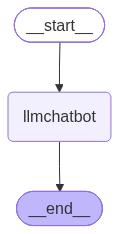

In [8]:
# graphbuilder is basically our state graph
graph_builder=StateGraph(State)

# in our graph we need start, chatbot and end respectively and the edges connecting them
# for this use graph api

# add node and pass the name which you want to give to the node and the node definition.mine is chatbott which i defined earlier
graph_builder.add_node("llmchatbot" , chatbot)

# add edges and pas the names 
graph_builder.add_edge(START , "llmchatbot")
graph_builder.add_edge("llmchatbot" , END)

# compile the graph for execution

graph_builder.compile()

In [9]:
graph = graph_builder.compile()
graph.invoke({"messages":"Hi"})
# now look at the output.The reducer add_messages did all the work.It converted user query into human message and appended the query and the model response in the messages variable that we created in the State

{'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='16077810-666d-4c07-8d32-ee9bd521ca6a'),
  AIMessage(content="It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 36, 'total_tokens': 59, 'completion_time': 0.039609369, 'completion_tokens_details': None, 'prompt_time': 0.002039896, 'prompt_tokens_details': None, 'queue_time': 0.005120884, 'total_time': 0.041649265}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fc722-d628-7cb3-995e-9caf179646b5-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 23, 'total_tokens': 59})]}

In [10]:
response = graph.invoke({"messages":"Hi"})

In [11]:
response["messages"][-1].content

"It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [12]:
# this will give us every thing like node name , variable name , metadata etc
#for event in graph.stream({"messages":"hi How are you?"}):
 #   print(event)
    

In [13]:
# and this is another way to stream messages
for event in graph.stream({"messages":"hi How are you?"}):
    # whenever we stream messages with graph.stream and want event values only so it only shows the AI message
    for value in event.values():
        print(value["messages"][-1].content)

I'm functioning properly, thank you for asking. I'm a large language model, so I don't have feelings like humans do, but I'm here to help answer any questions or provide information you might need. How can I assist you today?
